In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

matches = pd.read_csv('../dataset/matches.csv')
deliveries = pd.read_csv('../dataset/deliveries.csv')

print("Data loaded successfully!")

Data loaded successfully!


In [15]:
# Fix team name inconsistencies
team_name_map = {
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Delhi Capitals': 'Delhi Daredevils',
    'Punjab Kings': 'Kings XI Punjab',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

matches.replace(team_name_map, inplace=True)
deliveries.replace(team_name_map, inplace=True)

print("Team names standardised!")

Team names standardised!


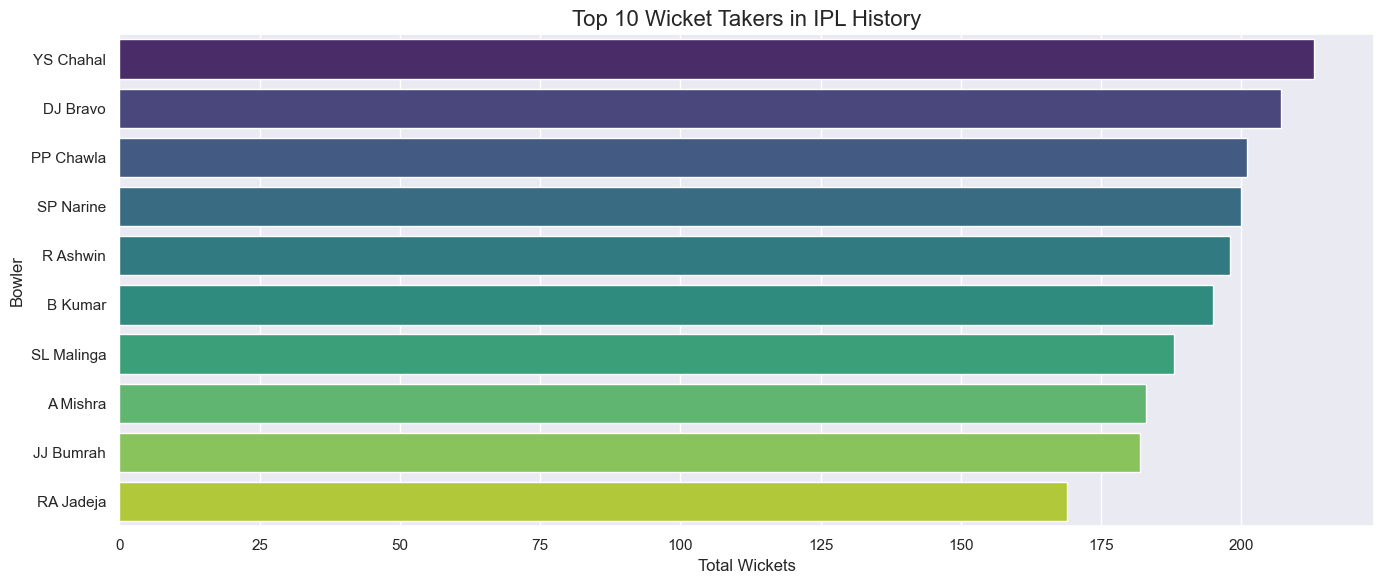

In [16]:
wickets = deliveries[deliveries['is_wicket'] == 1]
top_wickets = wickets.groupby('bowler').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_wickets.values, y=top_wickets.index, hue=top_wickets.index, palette='viridis', legend=False)
plt.title('Top 10 Wicket Takers in IPL History', fontsize=16)
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

In [17]:
bowler_stats = deliveries.groupby('bowler').agg(
    wickets=('is_wicket', 'sum'),
    balls=('is_wicket', 'count'),
    runs_conceded=('total_runs', 'sum')
).reset_index()

bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['balls'] * 6).round(2)
bowler_stats['bowling_avg'] = (bowler_stats['runs_conceded'] / bowler_stats['wickets'].replace(0, np.nan)).round(2)
bowler_stats = bowler_stats[bowler_stats['balls'] >= 240]
top_bowlers_table = bowler_stats.sort_values('wickets', ascending=False).head(10)
top_bowlers_table

,bowler,wickets,balls,runs_conceded,economy,bowling_avg
524,YS Chahal,213,3628,4681,7.74,21.98
119,DJ Bravo,207,3296,4436,8.08,21.43
348,PP Chawla,201,3895,5179,7.98,25.77
446,SP Narine,200,4146,4672,6.76,23.36
355,R Ashwin,198,4679,5435,6.97,27.45
71,B Kumar,195,4060,5051,7.46,25.90
438,SL Malinga,188,2974,3486,7.03,18.54
8,A Mishra,183,3444,4193,7.30,22.91
193,JJ Bumrah,182,3185,3840,7.23,21.10
373,RA Jadeja,169,3895,4917,7.57,29.09


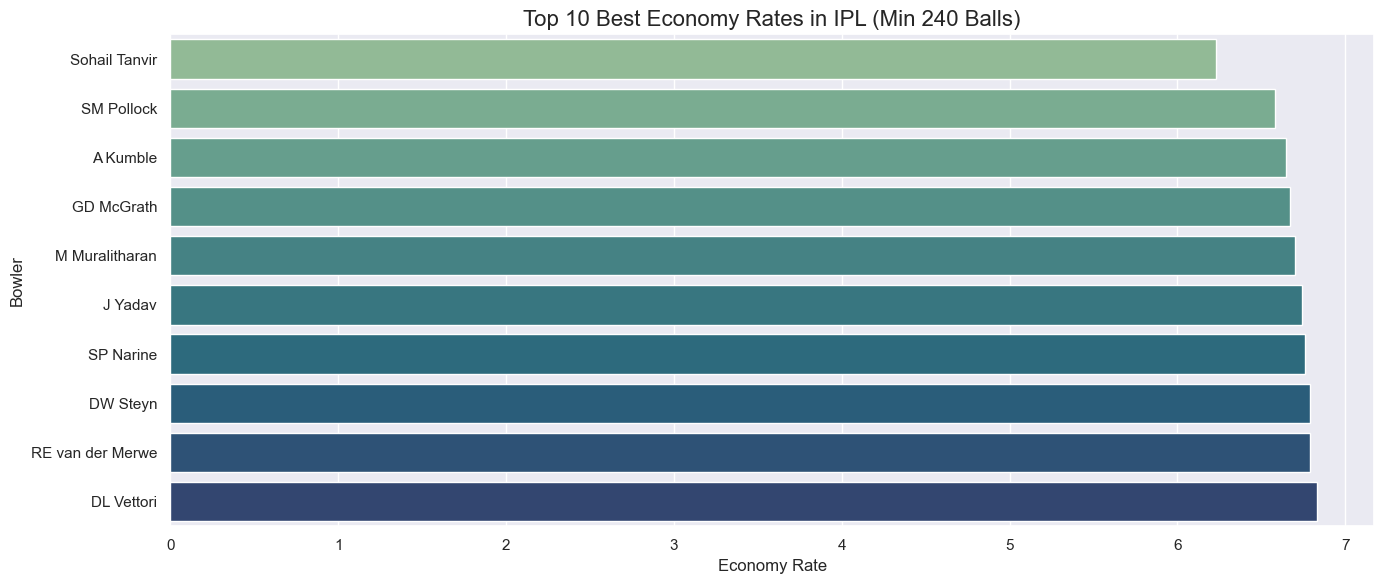

In [18]:
best_economy = bowler_stats[bowler_stats['balls'] >= 240].sort_values('economy').head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=best_economy['economy'], y=best_economy['bowler'], hue=best_economy['bowler'], palette='crest', legend=False)
plt.title('Top 10 Best Economy Rates in IPL (Min 240 Balls)', fontsize=16)
plt.xlabel('Economy Rate')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

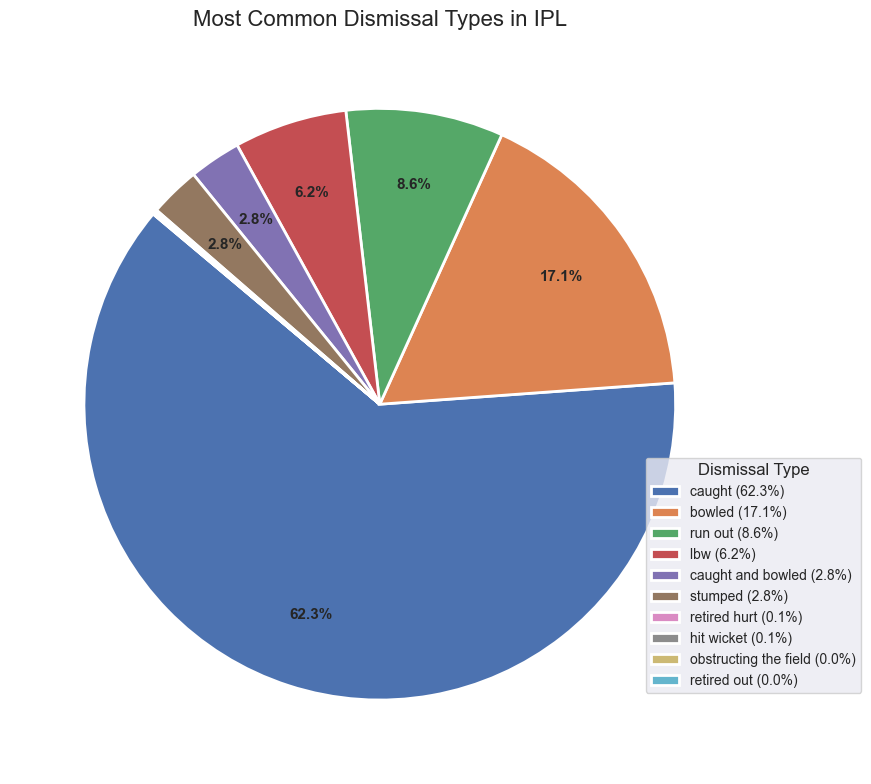

In [19]:
dismissals = deliveries[deliveries['is_wicket'] == 1]['dismissal_kind'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    dismissals.values,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 1 else '',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.legend(wedges, [f'{label} ({val/dismissals.sum()*100:.1f}%)' 
           for label, val in zip(dismissals.index, dismissals.values)],
           title="Dismissal Type",
           loc="lower left",
           bbox_to_anchor=(0.85, 0.1),
           fontsize=10)

plt.title('Most Common Dismissal Types in IPL', fontsize=16)
plt.tight_layout()
plt.show()

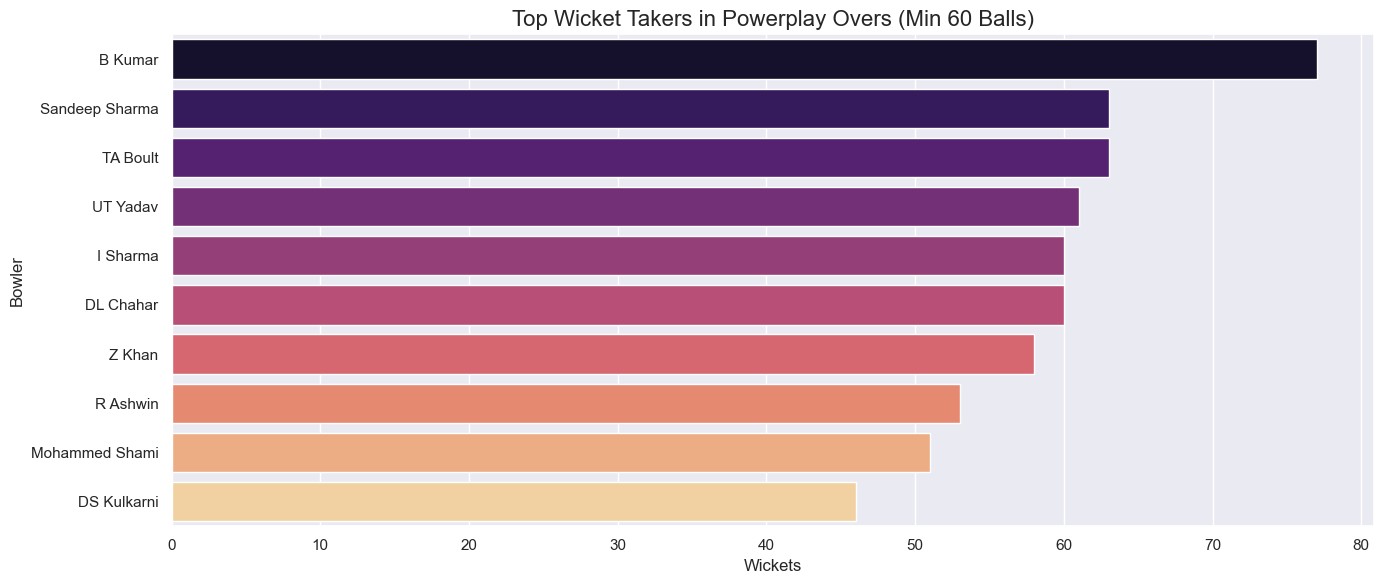

In [20]:
powerplay = deliveries[deliveries['over'] < 6]

pp_bowlers = powerplay.groupby('bowler').agg(
    wickets=('is_wicket', 'sum'),
    balls=('is_wicket', 'count'),
    runs=('total_runs', 'sum')
).reset_index()

pp_bowlers['economy'] = (pp_bowlers['runs'] / pp_bowlers['balls'] * 6).round(2)
pp_bowlers = pp_bowlers[pp_bowlers['balls'] >= 60].sort_values('wickets', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=pp_bowlers, x='wickets', y='bowler', hue='bowler', palette='magma', legend=False)
plt.title('Top Wicket Takers in Powerplay Overs (Min 60 Balls)', fontsize=16)
plt.xlabel('Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

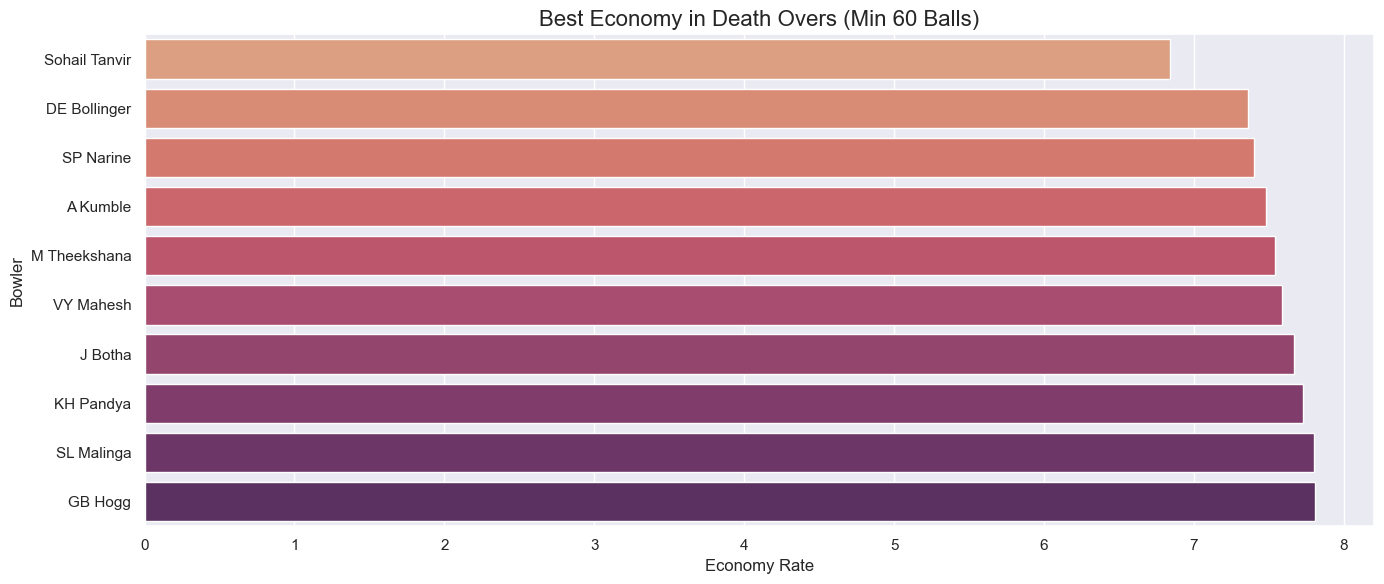

In [21]:
death = deliveries[deliveries['over'] >= 15]

death_bowlers = death.groupby('bowler').agg(
    wickets=('is_wicket', 'sum'),
    balls=('is_wicket', 'count'),
    runs=('total_runs', 'sum')
).reset_index()

death_bowlers['economy'] = (death_bowlers['runs'] / death_bowlers['balls'] * 6).round(2)
death_bowlers = death_bowlers[death_bowlers['balls'] >= 60].sort_values('economy').head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=death_bowlers, x='economy', y='bowler', hue='bowler', palette='flare', legend=False)
plt.title('Best Economy in Death Overs (Min 60 Balls)', fontsize=16)
plt.xlabel('Economy Rate')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

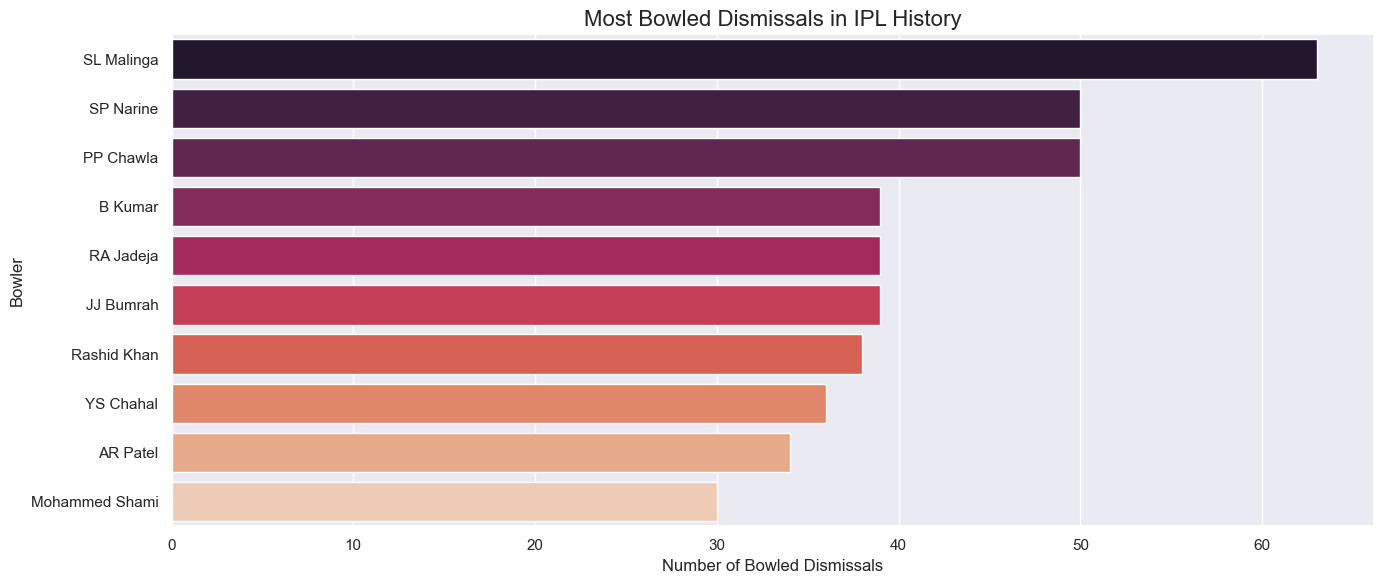

In [22]:
bowled = deliveries[deliveries['dismissal_kind'] == 'bowled'].groupby('bowler').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=bowled.values, y=bowled.index, hue=bowled.index, palette='rocket', legend=False)
plt.title('Most Bowled Dismissals in IPL History', fontsize=16)
plt.xlabel('Number of Bowled Dismissals')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

In [23]:
total_wickets = deliveries['is_wicket'].sum()
top_wicket_taker = wickets.groupby('bowler').size().idxmax()
top_wicket_count = wickets.groupby('bowler').size().max()
most_bowled = deliveries[deliveries['dismissal_kind'] == 'bowled'].groupby('bowler').size().idxmax()
best_economy_bowler = bowler_stats[bowler_stats['balls'] >= 240].sort_values('economy').iloc[0]['bowler']
most_common_dismissal = deliveries[deliveries['is_wicket'] == 1]['dismissal_kind'].value_counts().idxmax()

print("=== BOWLING SUMMARY ===")
print(f"Total wickets taken in IPL history: {total_wickets:,}")
print(f"All time top wicket taker: {top_wicket_taker} ({top_wicket_count} wickets)")
print(f"Most bowled dismissals: {most_bowled}")
print(f"Best economy rate (min 240 balls): {best_economy_bowler}")
print(f"Most common dismissal type: {most_common_dismissal}")

=== BOWLING SUMMARY ===
Total wickets taken in IPL history: 12,950
All time top wicket taker: YS Chahal (213 wickets)
Most bowled dismissals: SL Malinga
Best economy rate (min 240 balls): Sohail Tanvir
Most common dismissal type: caught
